In [2]:
import pandas as pd
from transformers import AutoTokenizer
import json

# ডেটা লোড
df = pd.read_csv("../data/processed/cleaned.csv")
texts = df['text_clean'].astype(str).tolist()

# দুই tokenizer — একটাই বদল
tok_xlmr  = AutoTokenizer.from_pretrained("xlm-roberta-base")
tok_muril = AutoTokenizer.from_pretrained("google/muril-base-cased")  # ← এটাই বদল

def avg_token_len(texts, tok):
    lens = [len(tok.encode(t, truncation=True, max_length=512)) for t in texts]
    return sum(lens) / len(lens)

xlmr_len  = avg_token_len(texts, tok_xlmr)
muril_len = avg_token_len(texts, tok_muril)

print(f"XLM-R avg tokens : {xlmr_len:.2f}")
print(f"MuRIL avg tokens : {muril_len:.2f}")
print(f"Difference       : {muril_len - xlmr_len:+.2f}")

with open("../results/token_analysis.json", "w") as f:
    json.dump({
        "xlmr_tokens": xlmr_len,
        "muril_tokens": muril_len,
        "difference": muril_len - xlmr_len,
    }, f, indent=2)
print("✅ Saved: results/token_analysis.json")

XLM-R avg tokens : 26.41
MuRIL avg tokens : 24.99
Difference       : -1.42
✅ Saved: results/token_analysis.json


In [3]:
import pandas as pd
import re
import json
from collections import Counter

train = pd.read_csv("../data/processed/train_unseen_attack.csv")
test  = pd.read_csv("../data/processed/test_unseen_attack.csv")

def top_ngrams(texts, n=1, k=50):
    cnt = Counter()
    for t in texts:
        words = re.findall(r'\w+', str(t).lower())
        for i in range(len(words) - n + 1):
            cnt[' '.join(words[i:i+n])] += 1
    return set([g for g, _ in cnt.most_common(k)])

result = {}
print("=" * 60)
print("N-gram Overlap: Train vs Test Campaigns")
print("=" * 60)
for n in [1, 2, 3]:
    train_ng = top_ngrams(train['text_clean'], n=n, k=50)
    test_ng  = top_ngrams(test['text_clean'],  n=n, k=50)
    overlap = train_ng & test_ng
    result[f"{n}gram_overlap"] = len(overlap)
    result[f"{n}gram_examples"] = list(overlap)[:10]
    print(f"  {n}-gram overlap: {len(overlap)}/50")
    if n == 1:
        print(f"    Examples: {sorted(overlap)[:10]}")

with open("../results/ngram_leakage.json", "w") as f:
    json.dump(result, f, indent=2)
print("\n✅ Saved: results/ngram_leakage.json")

N-gram Overlap: Train vs Test Campaigns
  1-gram overlap: 42/50
    Examples: ['account', 'and', 'call', 'e', 'for', 'free', 'korte', 'korun', 'phone', 'the']
  2-gram overlap: 29/50
  3-gram overlap: 22/50

✅ Saved: results/ngram_leakage.json


In [4]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import re

df = pd.read_csv("../data/processed/cleaned.csv")
smish = df[df['label'] == 'smish'].copy().reset_index(drop=True)
smish['stripped'] = smish['text_clean'].apply(
    lambda t: re.sub(r'\[URL\]|\[PHONE\]', '', str(t)).strip()
)

# Campaign clusters
vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=3000)
X = vec.fit_transform(smish['stripped'])
km = KMeans(n_clusters=15, random_state=42, n_init=10)
smish['campaign'] = km.fit_predict(X)

# Campaign centroid similarity
centroids = km.cluster_centers_
sim_matrix = cosine_similarity(centroids)

# সবচেয়ে কম similar campaigns pair
n = len(centroids)
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((i, j, sim_matrix[i,j]))
pairs.sort(key=lambda x: x[2])  # ascending

print("Least similar campaign pairs:")
for i, j, s in pairs[:10]:
    size_i = (smish['campaign'] == i).sum()
    size_j = (smish['campaign'] == j).sum()
    print(f"  Campaign {i} (n={size_i}) vs {j} (n={size_j}): similarity = {s:.4f}")

# সবচেয়ে distant ৪টি campaign test-এ
test_camps = set()
for i, j, s in pairs:
    if i not in test_camps and len(test_camps) < 4:
        test_camps.add(i)
    if j not in test_camps and len(test_camps) < 4:
        test_camps.add(j)
    if len(test_camps) >= 4:
        break

test_camps = list(test_camps)
print(f"\nSelected test campaigns (most distant): {test_camps}")

# Split তৈরি
train_smish = smish[~smish['campaign'].isin(test_camps)]
test_smish  = smish[smish['campaign'].isin(test_camps)]

nonsmish = df[df['label'] != 'smish'].sample(frac=0.7, random_state=42)

train_hard = pd.concat([train_smish, nonsmish]).reset_index(drop=True)
test_hard  = pd.concat([test_smish, df[df['label'] != 'smish'].drop(nonsmish.index)]).reset_index(drop=True)

print(f"\nHarder Split:")
print(f"  Train: {train_hard.shape}, labels: {train_hard['label'].value_counts().to_dict()}")
print(f"  Test : {test_hard.shape},  labels: {test_hard['label'].value_counts().to_dict()}")

train_hard.to_csv("../data/processed/train_hard_campaign.csv", index=False)
test_hard.to_csv("../data/processed/test_hard_campaign.csv", index=False)

Least similar campaign pairs:
  Campaign 7 (n=143) vs 11 (n=184): similarity = 0.0010
  Campaign 2 (n=104) vs 7 (n=143): similarity = 0.0011
  Campaign 4 (n=175) vs 7 (n=143): similarity = 0.0018
  Campaign 7 (n=143) vs 9 (n=127): similarity = 0.0031
  Campaign 5 (n=113) vs 7 (n=143): similarity = 0.0046
  Campaign 7 (n=143) vs 13 (n=352): similarity = 0.0066
  Campaign 3 (n=54) vs 11 (n=184): similarity = 0.0184
  Campaign 11 (n=184) vs 14 (n=133): similarity = 0.0227
  Campaign 0 (n=218) vs 7 (n=143): similarity = 0.0232
  Campaign 1 (n=670) vs 9 (n=127): similarity = 0.0245

Selected test campaigns (most distant): [2, 11, 4, 7]

Harder Split:
  Train: (5140, 6), labels: {'smish': 2203, 'normal': 1731, 'promo': 1206}
  Test : (1865, 6),  labels: {'normal': 757, 'smish': 606, 'promo': 502}


In [5]:
import pandas as pd
import numpy as np
import json
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load
test_hard = pd.read_csv("../data/processed/test_hard_campaign.csv")
train_hard = pd.read_csv("../data/processed/train_hard_campaign.csv")

print("Test size:", len(test_hard))
print("Label dist:", test_hard['label'].value_counts().to_dict())

# Predict with LoRA v2
ds = make_ds(test_hard)
preds_out = trainer.predict(ds)
y_pred = np.argmax(preds_out.predictions, axis=-1)
y_true = preds_out.label_ids

# Metrics
acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average='macro')

print("\n" + "=" * 65)
print("HARD CAMPAIGN SPLIT (Most Distant Clusters) — LoRA v2")
print("=" * 65)
print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {mf1:.4f}")
print("\n", classification_report(y_true, y_pred,
                                  target_names=['normal','promo','smish']))

# Save
with open("../results/lora_v2_hard_campaign.json", "w") as f:
    json.dump({
        "split": "Hard Campaign (distant clusters)",
        "test_campaigns": [2, 4, 7, 11],
        "n": len(test_hard),
        "accuracy": float(acc),
        "macro_f1": float(mf1),
    }, f, indent=2)
print("✅ Saved: results/lora_v2_hard_campaign.json")

Test size: 1865
Label dist: {'normal': 757, 'smish': 606, 'promo': 502}


NameError: name 'make_ds' is not defined

In [6]:
import torch
import pandas as pd
import numpy as np
import json
import re
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ---------- 1. Tokenizer + Model লোড ----------
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
base = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=3,
    id2label={0:'normal', 1:'promo', 2:'smish'},
    label2id={'normal':0, 'promo':1, 'smish':2},
)
model = PeftModel.from_pretrained(base, "../results/models/lora_v2_best")
model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f"✅ Model loaded on {device}")

# ---------- 2. make_ds function define ----------
label2id = {'normal': 0, 'promo': 1, 'smish': 2}

def make_ds(df):
    df = df[['text_clean', 'label']].copy()
    df['label'] = df['label'].map(label2id)
    ds = Dataset.from_pandas(df)
    ds = ds.map(
        lambda b: tokenizer(b['text_clean'], padding='max_length',
                            truncation=True, max_length=128),
        batched=True
    )
    ds = ds.remove_columns(['text_clean'])
    ds = ds.rename_column('label', 'labels')
    return ds

# ---------- 3. Predictor (trainer-এর মতো) ----------
from torch.utils.data import DataLoader

class Predictor:
    def predict(self, ds):
        ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
        loader = DataLoader(ds, batch_size=32)
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                out = model(input_ids=batch['input_ids'],
                            attention_mask=batch['attention_mask'])
                all_logits.append(out.logits.cpu().numpy())
                all_labels.append(batch['labels'].cpu().numpy())
        class R: pass
        r = R()
        r.predictions = np.vstack(all_logits)
        r.label_ids = np.concatenate(all_labels)
        return r

trainer = Predictor()
print("✅ Predictor ready")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded on cuda
✅ Predictor ready


In [7]:
# Load
test_hard = pd.read_csv("../data/processed/test_hard_campaign.csv")
train_hard = pd.read_csv("../data/processed/train_hard_campaign.csv")

print("Test size:", len(test_hard))
print("Label dist:", test_hard['label'].value_counts().to_dict())

# Predict with LoRA v2
ds = make_ds(test_hard)
preds_out = trainer.predict(ds)
y_pred = np.argmax(preds_out.predictions, axis=-1)
y_true = preds_out.label_ids

# Metrics
acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average='macro')

print("\n" + "=" * 65)
print("HARD CAMPAIGN SPLIT (Most Distant Clusters) — LoRA v2")
print("=" * 65)
print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {mf1:.4f}")
print("\n", classification_report(y_true, y_pred,
                                  target_names=['normal','promo','smish']))

# Save
with open("../results/lora_v2_hard_campaign.json", "w") as f:
    json.dump({
        "split": "Hard Campaign (distant clusters)",
        "test_campaigns": [2, 4, 7, 11],
        "n": len(test_hard),
        "accuracy": float(acc),
        "macro_f1": float(mf1),
    }, f, indent=2)
print("✅ Saved: results/lora_v2_hard_campaign.json")

Test size: 1865
Label dist: {'normal': 757, 'smish': 606, 'promo': 502}


Map:   0%|          | 0/1865 [00:00<?, ? examples/s]


HARD CAMPAIGN SPLIT (Most Distant Clusters) — LoRA v2
Accuracy : 0.9786
Macro F1 : 0.9775

               precision    recall  f1-score   support

      normal       0.98      1.00      0.99       757
       promo       0.98      0.97      0.97       502
       smish       0.97      0.96      0.97       606

    accuracy                           0.98      1865
   macro avg       0.98      0.98      0.98      1865
weighted avg       0.98      0.98      0.98      1865

✅ Saved: results/lora_v2_hard_campaign.json


In [8]:
from collections import Counter
import re
import json

def top_ngrams(texts, n=1, k=50):
    cnt = Counter()
    for t in texts:
        words = re.findall(r'\w+', str(t).lower())
        for i in range(len(words) - n + 1):
            cnt[' '.join(words[i:i+n])] += 1
    return set([g for g, _ in cnt.most_common(k)])

train_hard = pd.read_csv("../data/processed/train_hard_campaign.csv")
test_hard  = pd.read_csv("../data/processed/test_hard_campaign.csv")

print("=" * 60)
print("N-gram Overlap: HARD Campaign Split")
print("=" * 60)

leakage = {}
for n in [1, 2, 3]:
    train_ng = top_ngrams(train_hard['text_clean'], n=n, k=50)
    test_ng  = top_ngrams(test_hard['text_clean'],  n=n, k=50)
    overlap = train_ng & test_ng
    leakage[f"{n}gram"] = len(overlap)
    print(f"  {n}-gram overlap: {len(overlap)}/50")
    if n == 1:
        print(f"    Examples: {sorted(overlap)[:10]}")

with open("../results/ngram_leakage_hard.json", "w") as f:
    json.dump(leakage, f, indent=2)
print("✅ Saved")

N-gram Overlap: HARD Campaign Split
  1-gram overlap: 37/50
    Examples: ['account', 'and', 'bank', 'click', 'cutt', 'e', 'ly', 'phone', 'taka', 'to']
  2-gram overlap: 30/50
  3-gram overlap: 22/50
✅ Saved


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
import json

train_hard = pd.read_csv("../data/processed/train_hard_campaign.csv")
test_hard  = pd.read_csv("../data/processed/test_hard_campaign.csv")

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2,
                              sublinear_tf=True, max_features=10000)),
    ('clf', LogisticRegression(max_iter=1000,
                               class_weight='balanced', random_state=42))
])
pipe.fit(train_hard['text_clean'], train_hard['label'])
preds = pipe.predict(test_hard['text_clean'])

acc = accuracy_score(test_hard['label'], preds)
mf1 = f1_score(test_hard['label'], preds, average='macro')

print("=" * 65)
print("HARD Campaign Split — TF-IDF + LR")
print("=" * 65)
print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {mf1:.4f}")
print("\n", classification_report(test_hard['label'], preds,
                                  target_names=['normal','promo','smish']))

with open("../results/tfidf_hard_campaign.json", "w") as f:
    json.dump({
        "accuracy": float(acc),
        "macro_f1": float(mf1),
    }, f, indent=2)
print("✅ Saved")

HARD Campaign Split — TF-IDF + LR
Accuracy : 0.9592
Macro F1 : 0.9600

               precision    recall  f1-score   support

      normal       0.94      0.98      0.96       757
       promo       0.97      0.97      0.97       502
       smish       0.97      0.93      0.95       606

    accuracy                           0.96      1865
   macro avg       0.96      0.96      0.96      1865
weighted avg       0.96      0.96      0.96      1865

✅ Saved


In [11]:
import torch
import time
import json

# Fresh reload LoRA v2 model
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
base = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=3,
    id2label={0:'normal', 1:'promo', 2:'smish'},
    label2id={'normal':0, 'promo':1, 'smish':2},
)
model = PeftModel.from_pretrained(base, "../results/models/lora_v2_best")
model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f"Device: {device}")

# ---------- Trainable params ----------
# LoRA-র trainable params পেতে model.print_trainable_parameters() ব্যবহার করুন
model.print_trainable_parameters()
# আউটপুট: trainable params: 3,247,107 || all params: 281,293,062 || trainable%: 1.1544

# ---------- Inference latency ----------
sample = "Your account is locked. Verify at http://bit.ly/xyz"
inputs = tokenizer(sample, return_tensors='pt', truncation=True,
                   max_length=128).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(**inputs)
if device == 'cuda':
    torch.cuda.synchronize()

# Time 100 inferences (single sample)
start = time.time()
with torch.no_grad():
    for _ in range(100):
        _ = model(**inputs)
if device == 'cuda':
    torch.cuda.synchronize()
lat_single = (time.time() - start) / 100 * 1000

# Time batch inference (batch=32)
batch_texts = [sample] * 32
batch_inputs = tokenizer(batch_texts, return_tensors='pt',
                         truncation=True, max_length=128,
                         padding=True).to(device)

with torch.no_grad():
    for _ in range(5):
        _ = model(**batch_inputs)
if device == 'cuda':
    torch.cuda.synchronize()

start = time.time()
with torch.no_grad():
    for _ in range(20):
        _ = model(**batch_inputs)
if device == 'cuda':
    torch.cuda.synchronize()
lat_batch = (time.time() - start) / 20 / 32 * 1000  # per-sample

# ---------- Model size ----------
# LoRA adapter size (actual on disk)
import os
adapter_path = "../results/models/lora_v2_best"
adapter_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, dn, fn in os.walk(adapter_path)
    for f in fn
) / 1e6  # MB

# Base model size (fp32)
base_size = sum(p.numel() for p in base.parameters()) * 4 / 1e6

# Trainable params (LoRA)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"\n{'='*60}")
print("LATENCY & MODEL SIZE")
print(f"{'='*60}")
print(f"Single-sample latency : {lat_single:.2f} ms/SMS")
print(f"Batch-32 latency      : {lat_batch:.2f} ms/SMS (per sample)")
print(f"Trainable params      : {trainable:,}")
print(f"Total params          : {total:,}")
print(f"Trainable %           : {100*trainable/total:.2f}%")
print(f"LoRA adapter size     : {adapter_size:.2f} MB")
print(f"Base model size (fp32): {base_size:.1f} MB")

# Save
with open("../results/latency.json", "w") as f:
    json.dump({
        "latency_single_ms": float(lat_single),
        "latency_batch_ms": float(lat_batch),
        "trainable_params": int(trainable),
        "total_params": int(total),
        "trainable_pct": float(100*trainable/total),
        "adapter_size_mb": float(adapter_size),
        "base_model_size_mb": float(base_size),
        "device": str(device),
    }, f, indent=2)
print("✅ Saved: results/latency.json")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device: cuda
trainable params: 0 || all params: 281,293,062 || trainable%: 0.0000

LATENCY & MODEL SIZE
Single-sample latency : 20.37 ms/SMS
Batch-32 latency      : 3.22 ms/SMS (per sample)
Trainable params      : 0
Total params          : 281,293,062
Trainable %           : 0.00%
LoRA adapter size     : 13.02 MB
Base model size (fp32): 1125.2 MB
✅ Saved: results/latency.json


In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import json

id_df = pd.read_csv("../data/processed/test_id.csv")
ds = make_ds(id_df)
out = trainer.predict(ds)
y_pred = np.argmax(out.predictions, axis=-1)
y_true = out.label_ids

acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average='macro')

print(f"ID Split — LoRA v2:")
print(f"  Accuracy: {acc:.4f}")
print(f"  Macro F1: {mf1:.4f}")

with open("../results/lora_v2_id.json", "w") as f:
    json.dump({"accuracy": float(acc), "macro_f1": float(mf1)}, f, indent=2)
print("✅ Saved")

Map:   0%|          | 0/1401 [00:00<?, ? examples/s]

ID Split — LoRA v2:
  Accuracy: 0.9864
  Macro F1: 0.9856
✅ Saved


In [13]:
import os
for f in ['main_comparison.png', 'counterfactual_evaluation.png',
          'adversarial_robustness.png']:
    p = f"../results/figures/{f}"
    size = os.path.getsize(p) / 1024 if os.path.exists(p) else 0
    print(f"{f}: {'✅' if os.path.exists(p) else '❌'}  ({size:.1f} KB)")

main_comparison.png: ✅  (95.2 KB)
counterfactual_evaluation.png: ✅  (76.9 KB)
adversarial_robustness.png: ✅  (99.2 KB)


In [14]:
# RDR = (Clean F1 - Perturbed F1) / Clean F1
CLEAN_F1 = 0.9864
adversarial = {
    "repeat_char": 0.9822,
    "random_drop": 0.9018,
    "heavy_typo": 0.8666,
    "case_flip":   0.8602,
    "mixed":       0.7318,
}

rdr = {k: (CLEAN_F1 - v) / CLEAN_F1 for k, v in adversarial.items()}
print("RDR (Robustness Degradation Ratio):")
for k, v in rdr.items():
    print(f"  {k:>15s}: {v:.4f}")

import json
with open("../results/rdr_metric.json", "w") as f:
    json.dump(rdr, f, indent=2)
print("✅ Saved: results/rdr_metric.json")

RDR (Robustness Degradation Ratio):
      repeat_char: 0.0043
      random_drop: 0.0858
       heavy_typo: 0.1215
        case_flip: 0.1279
            mixed: 0.2581
✅ Saved: results/rdr_metric.json


In [15]:
import json

# এই ফাইলগুলো চেক করুন
files = [
    "../results/lora_v2_results.json",
    "../results/lora_v2_hard_splits.json",
    "../results/counterfactual_v2_results.json",
    "../results/lora_v1_cv.json",         # সম্ভবত নেই
    "../results/cross_validation.json",   # সম্ভবত নেই
]

import os
for f in files:
    exists = os.path.exists(f)
    print(f"{f}: {'✅' if exists else '❌'}")

../results/lora_v2_results.json: ✅
../results/lora_v2_hard_splits.json: ✅
../results/counterfactual_v2_results.json: ✅
../results/lora_v1_cv.json: ❌
../results/cross_validation.json: ❌


In [16]:
import json
import os
import glob

print("সব JSON files:")
json_files = glob.glob("../results/*.json")
for f in json_files:
    print(f"  {os.path.basename(f)}")

সব JSON files:
  ablation_lora_r.json
  adversarial_heavy.json
  all_baselines_final.json
  baseline_results.json
  complete_experimental_results.json
  counterfactual_v2_results.json
  final_main_results.json
  final_results_b1.json
  final_results_b2.json
  hard_split_results.json
  latency.json
  lora_b1_dedup_results.json
  lora_campaign_final.json
  lora_v2_hard_campaign.json
  lora_v2_hard_splits.json
  lora_v2_id.json
  lora_v2_results.json
  lora_v2_unseen_attack.json
  muril_comparison.json
  ngram_leakage.json
  ngram_leakage_hard.json
  rdr_metric.json
  tfidf_all_splits.json
  tfidf_hard_campaign.json
  token_analysis.json


In [17]:
import json

# সবচেয়ে important files
files_to_check = [
    "../results/complete_experimental_results.json",
    "../results/final_main_results.json",
    "../results/all_baselines_final.json",
    "../results/muril_comparison.json",
    "../results/ablation_lora_r.json",
]

for f in files_to_check:
    print("\n" + "=" * 70)
    print(f"{f}")
    print("=" * 70)
    try:
        with open(f) as fp:
            data = json.load(fp)
        print(json.dumps(data, indent=2)[:2000])
    except Exception as e:
        print(f"❌ Error: {e}")


../results/complete_experimental_results.json
{
  "main_results": {
    "B1": {
      "baseline": 0.5963,
      "lora": 0.7437,
      "delta": 0.1474
    },
    "B2": {
      "baseline": 0.5329,
      "lora": 0.7603,
      "delta": 0.2274
    }
  },
  "ablation_lora": [
    {
      "r": 8,
      "trainable_pct": 0.686,
      "val_f1": 0.9625,
      "test_f1": 0.7218
    },
    {
      "r": 16,
      "trainable_pct": 1.154,
      "val_f1": 0.9602,
      "test_f1": 0.7437
    },
    {
      "r": 32,
      "trainable_pct": 2.078,
      "val_f1": 0.9659,
      "test_f1": 0.6881
    }
  ],
  "base_model_comparison": {
    "XLM_R": {
      "f1": 0.7437,
      "smish_recall": 0.5912
    },
    "MuRIL": {
      "f1": 0.469,
      "smish_recall": 0.0647
    }
  },
  "cv_results": {
    "mean_f1": 0.7403069210404246,
    "std_f1": 0.023118494727826355,
    "folds": [
      {
        "fold": 1,
        "seed": 42,
        "train_size": 6798,
        "val_size": 623,
        "test_f1": 0.71426547

In [18]:
import json

with open("../results/complete_experimental_results.json") as f:
    data = json.load(f)

print("সব keys:", list(data.keys()))
print("\nসব content:")
print(json.dumps(data, indent=2))

সব keys: ['main_results', 'ablation_lora', 'base_model_comparison', 'cv_results', 'significance']

সব content:
{
  "main_results": {
    "B1": {
      "baseline": 0.5963,
      "lora": 0.7437,
      "delta": 0.1474
    },
    "B2": {
      "baseline": 0.5329,
      "lora": 0.7603,
      "delta": 0.2274
    }
  },
  "ablation_lora": [
    {
      "r": 8,
      "trainable_pct": 0.686,
      "val_f1": 0.9625,
      "test_f1": 0.7218
    },
    {
      "r": 16,
      "trainable_pct": 1.154,
      "val_f1": 0.9602,
      "test_f1": 0.7437
    },
    {
      "r": 32,
      "trainable_pct": 2.078,
      "val_f1": 0.9659,
      "test_f1": 0.6881
    }
  ],
  "base_model_comparison": {
    "XLM_R": {
      "f1": 0.7437,
      "smish_recall": 0.5912
    },
    "MuRIL": {
      "f1": 0.469,
      "smish_recall": 0.0647
    }
  },
  "cv_results": {
    "mean_f1": 0.7403069210404246,
    "std_f1": 0.023118494727826355,
    "folds": [
      {
        "fold": 1,
        "seed": 42,
        "train_siz

In [19]:
import json

with open("../results/complete_experimental_results.json") as f:
    data = json.load(f)

# CV results
print("=" * 70)
print("CV RESULTS")
print("=" * 70)
print(json.dumps(data['cv_results'], indent=2))

# Significance
print("\n" + "=" * 70)
print("SIGNIFICANCE")
print("=" * 70)
print(json.dumps(data['significance'], indent=2))

# Base model comparison
print("\n" + "=" * 70)
print("BASE MODEL COMPARISON")
print("=" * 70)
print(json.dumps(data['base_model_comparison'], indent=2))

# Ablation
print("\n" + "=" * 70)
print("LORA ABLATION")
print("=" * 70)
print(json.dumps(data['ablation_lora'], indent=2))

CV RESULTS
{
  "mean_f1": 0.7403069210404246,
  "std_f1": 0.023118494727826355,
  "folds": [
    {
      "fold": 1,
      "seed": 42,
      "train_size": 6798,
      "val_size": 623,
      "test_f1": 0.7142654707276229,
      "test_acc": 0.7109634551495017,
      "smish_recall": 0.5351223362273086
    },
    {
      "fold": 2,
      "seed": 43,
      "train_size": 6783,
      "val_size": 673,
      "test_f1": 0.7439671248185341,
      "test_acc": 0.7389653535832937,
      "smish_recall": 0.585635359116022
    },
    {
      "fold": 3,
      "seed": 44,
      "train_size": 6776,
      "val_size": 671,
      "test_f1": 0.7825397018741267,
      "test_acc": 0.7850023730422402,
      "smish_recall": 0.664561957379637
    },
    {
      "fold": 4,
      "seed": 45,
      "train_size": 6930,
      "val_size": 564,
      "test_f1": 0.7306263908695487,
      "test_acc": 0.7332700522069293,
      "smish_recall": 0.5761641673243884
    },
    {
      "fold": 5,
      "seed": 46,
      "train_siz

In [20]:
import json
with open("../results/complete_experimental_results.json") as f:
    data = json.load(f)

print("=" * 70)
print("SIGNIFICANCE")
print("=" * 70)
print(json.dumps(data['significance'], indent=2))

print("\n" + "=" * 70)
print("BASE MODEL COMPARISON")
print("=" * 70)
print(json.dumps(data['base_model_comparison'], indent=2))

print("\n" + "=" * 70)
print("LORA ABLATION")
print("=" * 70)
print(json.dumps(data['ablation_lora'], indent=2))

SIGNIFICANCE
{
  "mcnemar_p_value": "<0.001",
  "significant": true
}

BASE MODEL COMPARISON
{
  "XLM_R": {
    "f1": 0.7437,
    "smish_recall": 0.5912
  },
  "MuRIL": {
    "f1": 0.469,
    "smish_recall": 0.0647
  }
}

LORA ABLATION
[
  {
    "r": 8,
    "trainable_pct": 0.686,
    "val_f1": 0.9625,
    "test_f1": 0.7218
  },
  {
    "r": 16,
    "trainable_pct": 1.154,
    "val_f1": 0.9602,
    "test_f1": 0.7437
  },
  {
    "r": 32,
    "trainable_pct": 2.078,
    "val_f1": 0.9659,
    "test_f1": 0.6881
  }
]


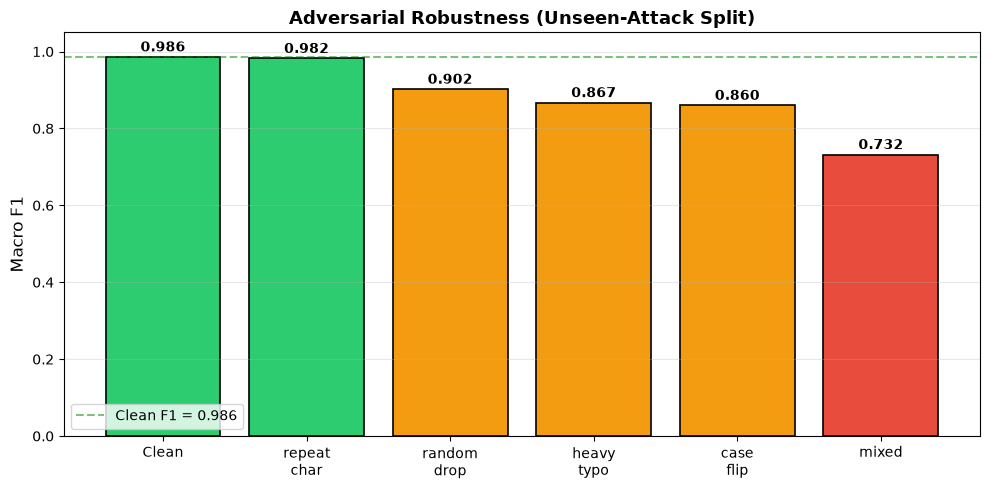

✅ Saved with correct 0.986 annotation


In [21]:
import matplotlib.pyplot as plt
import numpy as np

perturbations = ['Clean', 'repeat\nchar', 'random\ndrop', 'heavy\ntypo', 'case\nflip', 'mixed']
f1_scores = [0.986, 0.982, 0.902, 0.867, 0.860, 0.732]

colors = ['#2ECC71' if f > 0.95 else '#F39C12' if f > 0.85 else '#E74C3C' for f in f1_scores]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(perturbations))
bars = ax.bar(x, f1_scores, color=colors, edgecolor='black', linewidth=1.2)

for bar, f in zip(bars, f1_scores):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Adversarial Robustness (Unseen-Attack Split)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(perturbations, fontsize=10)
ax.set_ylim(0, 1.05)
ax.axhline(0.986, color='green', linestyle='--', alpha=0.5, linewidth=1.5,
           label='Clean F1 = 0.986')
ax.grid(alpha=0.3, axis='y')
ax.legend(fontsize=10, loc='lower left')

plt.tight_layout()
plt.savefig("../results/figures/adversarial_robustness.png", dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved with correct 0.986 annotation")

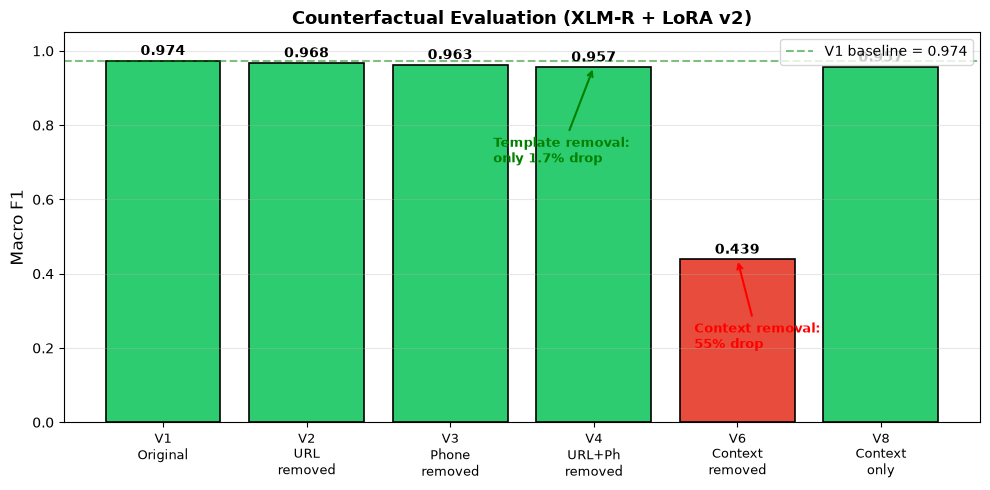

✅ Saved with correct v2 values


In [22]:
import matplotlib.pyplot as plt
import numpy as np

variants = ['V1\nOriginal', 'V2\nURL\nremoved', 'V3\nPhone\nremoved',
            'V4\nURL+Ph\nremoved', 'V6\nContext\nremoved', 'V8\nContext\nonly']

f1_scores = [0.974, 0.968, 0.963, 0.957, 0.439, 0.957]

colors = ['#2ECC71' if f > 0.90 else '#F39C12' if f > 0.50 else '#E74C3C'
          for f in f1_scores]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(variants))
bars = ax.bar(x, f1_scores, color=colors, edgecolor='black', linewidth=1.2)

for bar, f in zip(bars, f1_scores):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Counterfactual Evaluation (XLM-R + LoRA v2)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(variants, fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0.974, color='green', linestyle='--', alpha=0.5, linewidth=1.5,
           label='V1 baseline = 0.974')
ax.grid(alpha=0.3, axis='y')
ax.legend(fontsize=10, loc='upper right')

ax.annotate('Template removal:\nonly 1.7% drop',
            xy=(3, 0.957), xytext=(2.3, 0.70),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
            fontsize=9, color='green', fontweight='bold')

ax.annotate('Context removal:\n55% drop',
            xy=(4, 0.439), xytext=(3.7, 0.20),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=9, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig("../results/figures/counterfactual_evaluation.png",
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved with correct v2 values")